In [12]:
import pandas as pd

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(train_df.head())
print(test_df.head())

print(train_df.isnull().sum())

   employee_id         department  ... avg_training_score is_promoted
0        65438  Sales & Marketing  ...                 49           0
1        65141         Operations  ...                 60           0
2         7513  Sales & Marketing  ...                 50           0
3         2542  Sales & Marketing  ...                 50           0
4        48945         Technology  ...                 73           0

[5 rows x 13 columns]
   employee_id         department  ... awards_won? avg_training_score
0         8724         Technology  ...           0                 77
1        74430                 HR  ...           0                 51
2        72255  Sales & Marketing  ...           0                 47
3        38562        Procurement  ...           0                 65
4        64486            Finance  ...           0                 61

[5 rows x 12 columns]
employee_id                0
department                 0
region                     0
education               240

In [13]:
def preprocess(df):
    df = df.copy()

    # fill missing value education
    mode_education = df['education'].mode()[0]
    df['education'] = df['education'].fillna(mode_education)

    # fill missing value rating
    median_rating = df['previous_year_rating'].median()
    df['previous_year_rating'] = df['previous_year_rating'].fillna(median_rating)

    # convert category to num
    categorical_columns = [
        'department',
        'region',
        'education',
        'gender',
        'recruitment_channel'
    ]

    for col in categorical_columns:
        df[col] = pd.factorize(df[col])[0]

    return df


train_df = preprocess(train_df)
test_df = preprocess(test_df)

print(train_df.isnull().sum())
print(test_df.isnull().sum())

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64
employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
dtype: int64


In [14]:
# decision tree - entropy
import numpy as np

def entropy(y):
    _, counts = np.unique(y, 
        return_counts=True)

    result = 0

    for count in counts:
        p = count / len(y)
        result -= p * np.log2(p)

    return result


def information_gain(data, feature, target):
    total_entropy = entropy(data[target])

    values = data[feature].unique()

    weighted_entropy = 0

    for value in values:
        subset = data[data[feature] == value]

        weight = len(subset) / len(data)

        weighted_entropy += (
            weight * entropy(subset[target])
        )

    return total_entropy - weighted_entropy


# find the best feature
def best_feature(data, features, target):
    best_gain = -1
    best = None
    
    for feature in features:
        gain = information_gain(
            data,
            feature,
            target
        )

        if gain > best_gain:
            best_gain = gain
            best = feature

    return best


def build_tree(data, features, target):

    labels = data[target]

    if len(labels.unique()) == 1:
        return labels.iloc[0]

    if len(features) == 0:
        return labels.mode()[0]

    root = best_feature(
        data,
        features,
        target
    )

    tree = {root: {}}

    remaining = [
        f for f in features
        if f != root
    ]

    for value in data[root].unique():

        subset = data[data[root] == value]

        if len(subset) == 0:
            tree[root][value] = labels.mode()[0]

        else:
            tree[root][value] = build_tree(
                subset,
                remaining,
                target
            )

    return tree


def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree
    
    root = list(tree.keys())[0]

    value = sample[root]

    if value not in tree[root]:
        return 0
    
    return predict(
        tree[root][value],
        sample
    )


In [15]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)


# Training
TARGET = "is_promoted"

features = [
    col for col in train_df.columns
    if col not in ["employee_id", TARGET]
]

print(features)

tree = build_tree(
    train_data,
    features,
    TARGET
)

print(tree)

['department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score']
{'avg_training_score': {np.int64(48): {'region': {np.int64(2): np.int64(0), np.int64(5): {'age': {np.int64(33): {'length_of_service': {np.int64(5): np.int64(0), np.int64(3): np.int64(0), np.int64(6): np.int64(0), np.int64(8): {'department': {np.int64(7): np.int64(1), np.int64(0): np.int64(0)}}, np.int64(7): np.int64(0), np.int64(10): np.int64(0), np.int64(2): np.int64(0)}}, np.int64(43): np.int64(0), np.int64(50): np.int64(0), np.int64(41): {'length_of_service': {np.int64(5): np.int64(0), np.int64(2): np.int64(0), np.int64(13): np.int64(0), np.int64(6): np.int64(0), np.int64(12): {'education': {np.int64(1): np.int64(1), np.int64(0): np.int64(0)}}, np.int64(10): np.int64(0), np.int64(1): np.int64(0), np.int64(3): np.int64(0), np.int64(4): np.int64(1)}}, np.int64(60): np.int64(0), np.int64(34): {'recruitment_cha

In [16]:
correct = 0

for _, row in test_data.iterrows():
    
    pred = predict(tree, row)

    if pred == row['is_promoted']:
        correct += 1

accuracy = correct / len(test_data)
print(f'Accuracy:  {accuracy:.2%}')

Accuracy:  90.48%


In [17]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

tp = fp = tn = fn = 0

for _, row in test_data.iterrows():

    actual = row["is_promoted"]
    pred = predict(tree, row)

    y_true.append(actual)
    y_pred.append(pred)

    if actual == 1 and pred == 1:
        tp += 1

    elif actual == 0 and pred == 0:
        tn += 1

    elif actual == 0 and pred == 1:
        fp += 1

    elif actual == 1 and pred == 0:
        fn += 1

print(f"TP = {tp}")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")

cm = confusion_matrix(y_true, y_pred)

TP = 310
TN = 9608
FP = 446
FN = 598


<module 'matplotlib' from 'C:\\Users\\evang\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\matplotlib\\__init__.py'>

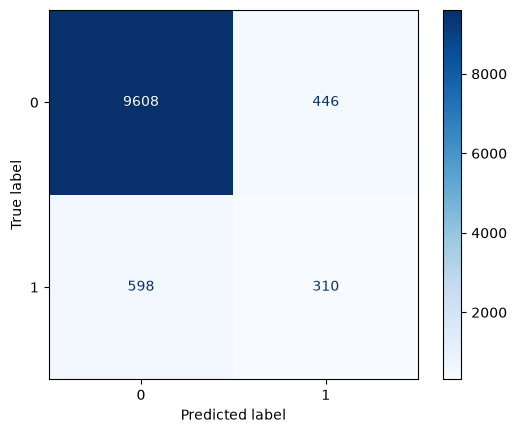

In [20]:
import matplotlib as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")
plt

In [18]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.41005291005291006
Recall: 0.34140969162995594
F1: 0.37259615384615385
